# Assignmnt IV
-Visualization

In [5]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## PART-I
Using the CSV files in the data/ folder and the visualization techniques covered so
far, complete the following exercises:

In [4]:
#Load datasets
earthquakes = pd.read_csv('data/earthquakes.csv')
faang = pd.read_csv('data/faang.csv')
parsed = pd.read_csv('data/parsed.csv')


#### 1. Rolling Line Plot (faang.csv):
Plot the rolling 20-day minimum of Facebook’s (ticker == 'FB') closing price using the pandas plot() method.

In [6]:
fb = faang[faang['ticker'] == 'FB'].copy()

fb = fb.sort_values('date')
fb['rolling_min_20'] = fb['close'].rolling(window=20).min()

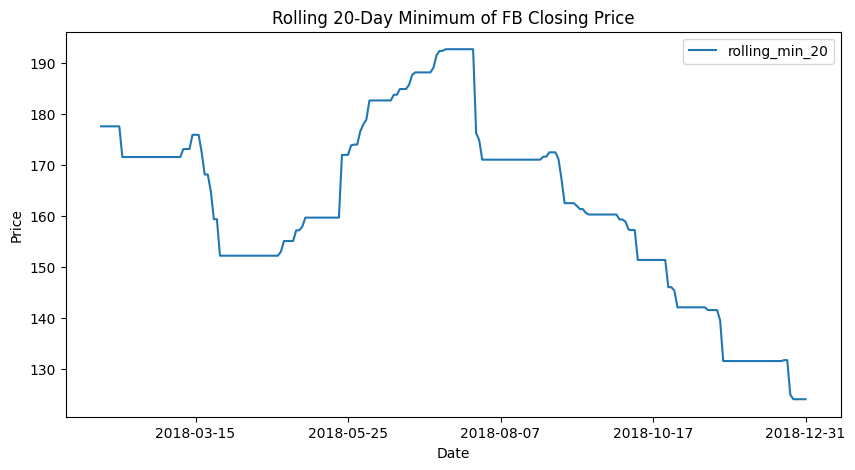

In [8]:
fb.plot(x='date', y='rolling_min_20', figsize=(10,5), title = 'Rolling 20-Day Minimum of FB Closing Price')

plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

#### 2. Histogram + KDE (faang.csv):
For Facebook, calculate the daily change from open to close and create:

    ○ A histogram

    ○ A KDE (Kernel Density Estimate) plot

Display both on the same figure.

In [9]:
fb['daily_change'] = fb['close']- fb['open']

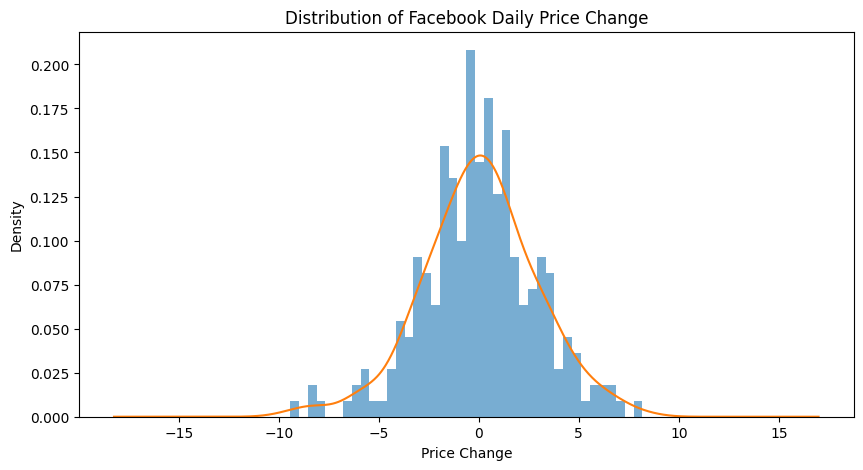

In [11]:
plt.figure(figsize=(10,5))

#Histogram
fb['daily_change'].plot(kind='hist', bins=40, density=True, alpha=0.6)

#KDE
fb['daily_change'].plot(kind='kde')

plt.title("Distribution of Facebook Daily Price Change")
plt.xlabel("Price Change")
plt.show()

#### 3. Box Plots by magType (earthquakes.csv):
Using earthquake data for Indonesia only, create box plots showing the distribution of magnitude for each magType.

In [12]:
indo_eq = earthquakes[earthquakes['parsed_place'].str.contains("Indonesia", na=False)]

<Figure size 1000x500 with 0 Axes>

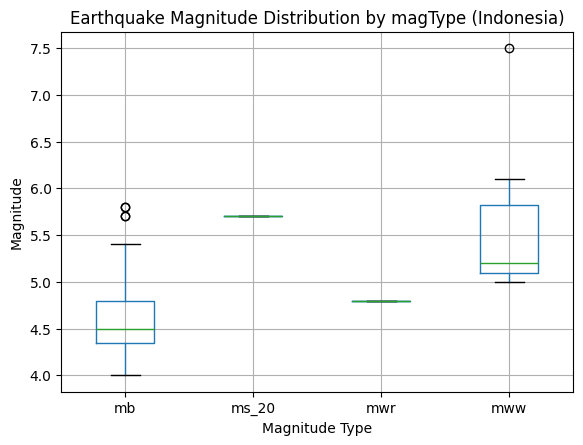

In [14]:
plt.figure(figsize=(10,5))
indo_eq.boxplot(column = 'mag', by = 'magType')

plt.title("Earthquake Magnitude Distribution by magType (Indonesia)")
plt.suptitle("")
plt.xlabel("Magnitude Type")
plt.ylabel("Magnitude")
plt.show()

#### 4. Weekly High–Low Difference (faang.csv):
For Facebook, calculate the weekly:

    ○ Maximum high

    ○ Minimum low

    ○ Then plot a single line showing the difference between them over time.

In [18]:
fb['date'] = pd.to_datetime(fb['date'])
fb_week = fb.set_index('date')

weekly_high = fb_week['high'].resample("W").max()
weekly_low = fb_week['low'].resample("W").min()

weekly_diff = weekly_high - weekly_low

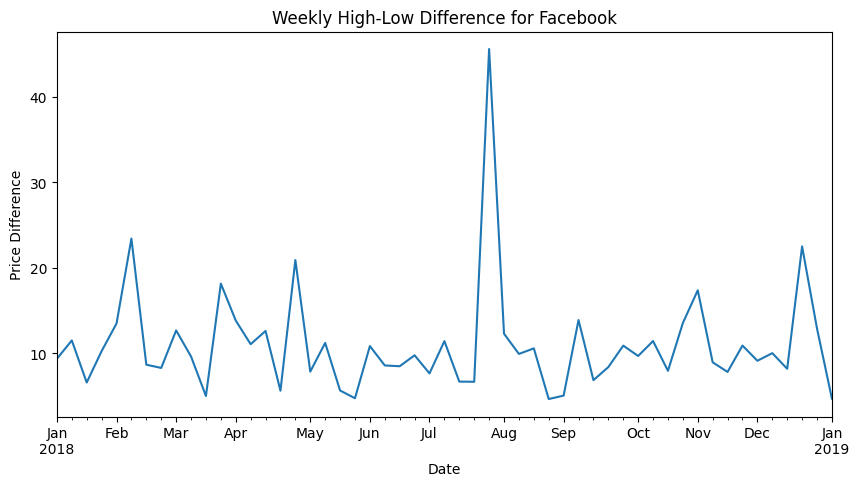

In [19]:
weekly_diff.plot(figsize=(10,5), title = 'Weekly High-Low Difference for Facebook')

plt.ylabel("Price Difference")
plt.xlabel("Date")
plt.show()

#### 5. After-Hours Trading Analysis (faang.csv):
Using matplotlib and pandas, create two side-by-side subplots analyzing the effect of after-hours trading on Facebook’s stock price:

Subplot 1:

    ○ Line plot of the daily difference between that day’s open price and the
    previous day’s close.
Subplot 2:

    ○ Bar plot showing the monthly net effect of this difference using
    resample().
    ○ Color bars green for gains and red for losses.
    ○ Modify the x-axis to show three-letter month abbreviations (e.g., Jan, Feb,
    Mar).

In [21]:
fb['prev_close'] = fb['close'].shift()
fb['after_hours_diff'] = fb['open'] - fb['close']

fb['date'] = pd.to_datetime(fb['date'])
fb_after = fb.set_index('date')

montly_effect = fb_after['after_hours_diff'].resample("ME").sum()

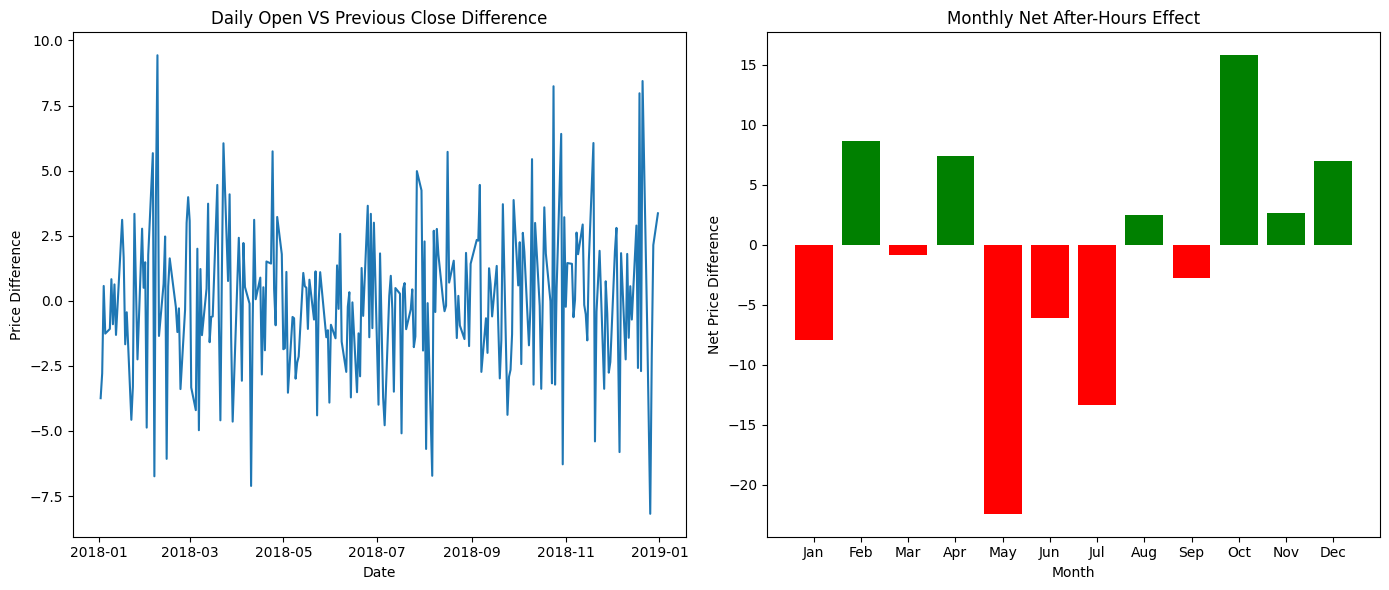

In [23]:
fig, axes = plt.subplots(1,2, figsize= (14,6))

#Subplot 1
axes[0].plot(fb_after.index, fb_after['after_hours_diff'])
axes[0].set_title("Daily Open VS Previous Close Difference")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price Difference")

#Subplot 2
colors = ['green' if val>0 else 'red' for val in montly_effect]

axes[1].bar(montly_effect.index.strftime("%b"), montly_effect, color = colors)
axes[1].set_title("Monthly Net After-Hours Effect")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Net Price Difference")

plt.tight_layout()
plt.show()